# Heat Surface Forcing

For the moment, I am taking some random value for a constant surface heat forcing. Later this will be based on ERA5.

In [1]:
import numpy as np
import xmitgcm.utils
import matplotlib.pyplot as plt

In [2]:
# where to save binaries
dir_binaries = "../../MITgcm/so_plumes/binaries/"

## Regional Set-Up

In [3]:
# horizontal grid
lat_slice = slice(-63,-55)
lon_slice = slice(0,8)
dx = 0.5 # [deg]
dy = 0.5 # [deg]
Nx = int((lon_slice.stop-lon_slice.start)/dx)
Ny = int((lat_slice.stop-lat_slice.start)/dy)

### Constant Forcing

In [ ]:
# forcing value
Q0 = 100

# forcing field
Q_surf = np.full((Nx,Ny), Q0)

# write to binary
suffix = f"_{Q0}W_uniform_{Nx}x{Ny}"
xmitgcm.utils.write_to_binary(Q_surf.flatten(order='F'), dir_binaries+"Q_surf"+suffix+".bin")

### North South Gradient Forcing

The idea here is to have stronger heat loss in the South than in the North of the domain. Currently, this is not working in the non-hydrostatic set up yet. Also, I am not sure yet how y maps to south/north (is lower y more north or more south? at the moment it does not matter yet).

In [4]:
# max forcing (S)
Qmax = 1000
# min forcing (N)
Qmin = 0

# empty forcing field
Q_surf = np.empty((Nx,Ny))

# fill with linear gradient in y direction
for j in range(Ny):
    Q_surf[:,j] = Qmin + (Qmax - Qmin)*(j/(Ny-1))

# write to binary
suffix = f"_Ygradient{Qmin}-{Qmax}W_{Nx}x{Ny}"
xmitgcm.utils.write_to_binary(Q_surf.flatten(order='F'), dir_binaries+"Q_surf"+suffix+".bin")

### Center Forcing

Just force the center grid cell.

In [ ]:
# forcing value
Q0 = 500
Q_env = 0

# forcing field
Q_surf = np.full((Nx,Ny), Q_env)

# fill center cell
Q_surf[Nx//2,Ny//2] = Q0

# write to binary
suffix = f"_centercol{Q0}W_rest{Q_env}W_{Nx}x{Ny}"
xmitgcm.utils.write_to_binary(Q_surf.flatten(order='F'), dir_binaries+"Q_surf"+suffix+".bin")

## Small-Scale Setup

### Lead - Rowans Function

In [28]:
# import Rowan's forcing field
rowans_lead_name = "bin_forc_Q_36x66x594_100m_lead"
r_filename = rowans_lead_name + ".bin"
Q = xmitgcm.utils.read_raw_data('../../MITgcm/so_plumes/input/' + r_filename, shape=(36,66,594), dtype=np.dtype('>f4') ) # shape is (time, X, Y)

In [42]:
# replace 200W cells with new value
val = 500
Q_new = np.where(Q==200, val, Q)
out_filename = rowans_lead_name + f"_{val}W.bin"
# write binary
xmitgcm.utils.write_to_binary(Q_new.flatten(order='C'), '../../MITgcm/so_plumes/input/' + out_filename)

[[  0. 200. 200. ... 200. 200.   0.]
 [  0. 200. 200. ... 200. 200.   0.]
 [  0. 200. 200. ... 200. 200.   0.]
 ...
 [  0. 200. 200. ... 200. 200.   0.]
 [  0. 200. 200. ... 200. 200.   0.]
 [  0. 200. 200. ... 200. 200.   0.]]


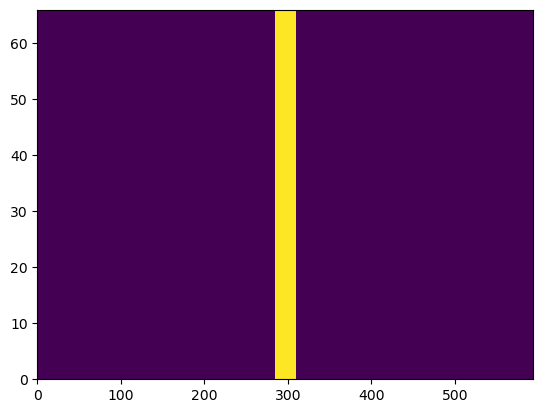

In [6]:
# visualize salt flux field
plt.pcolormesh(Q[24,:,:])
print(Q[10,:,284:311])

In [21]:
Q.shape

(36, 66, 594)

In [32]:
np.where(Q==200)

(array([ 0,  0,  0, ..., 24, 24, 24], shape=(41250,)),
 array([ 0,  0,  0, ..., 65, 65, 65], shape=(41250,)),
 array([285, 286, 287, ..., 307, 308, 309], shape=(41250,)))

In [22]:
 np.unique(np.where(Q==200)[2])

array([285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297,
       298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309])

=> the lead extends from cell 285 to incl. 309 in y-direction

### Lead - Constant Forcing

In [41]:
Q_const = np.zeros((36,66,594))
val = 500
Q_const[:,:,285:310] = val

# write binary
out_filename = rowans_lead_name + f"_{val}W-const.bin"
xmitgcm.utils.write_to_binary(Q_const.flatten(order='C'), '../../MITgcm/so_plumes/input/' + out_filename)

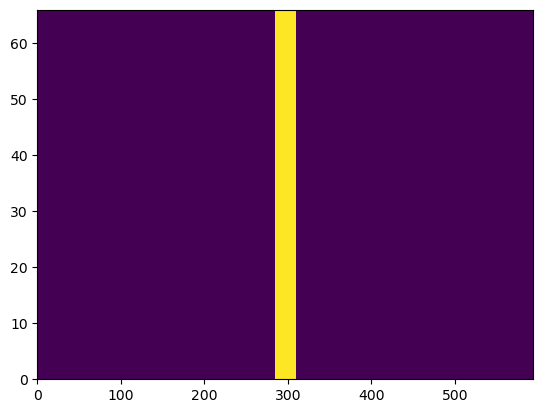

In [40]:
# visualize forcing field
plt.pcolormesh(Q_const[1,:,:])